In [24]:
import numpy as np
import matplotlib.pyplot as plt
import os
import random
import pandas as pd

from astropy.io import fits
from astropy.table import Table
from scipy.signal import detrend
from astropy.timeseries import LombScargle

In [2]:
#Data Upload

VVV_data = fits.open('VVV_Sample.fits')

Id_b278, Id_b279 = VVV_data[1].data,VVV_data[11].data

Ks_b278, Ks_b279 = VVV_data[2].data, VVV_data[12].data
Ks_err_b278, Ks_err_b279 = VVV_data[5].data, VVV_data[15].data
Ks_mjd_b278, Ks_mjd_b279 = VVV_data[8].data, VVV_data[18].data

#Removing np.nan 

# Remove missing values (NaNs) from all Ks-related data arrays

def remove_nans(array2d):
    return [row[~np.isnan(row)] for row in array2d]

def _safe_norm(x):
    xmin, xmax = np.min(x), np.max(x)
    return (x - xmin) / (xmax - xmin)

Ks_b278 = remove_nans(Ks_b278)
Ks_b279 = remove_nans(Ks_b279)

Ks_err_b278 = remove_nans(Ks_err_b278)
Ks_err_b279 = remove_nans(Ks_err_b279)

Ks_mjd_b278 = remove_nans(Ks_mjd_b278)
Ks_mjd_b279 = remove_nans(Ks_mjd_b279)

In [3]:
VVV_data.info()

Filename: VVV_Sample.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      11   ()      
  1  ID_B278       1 ImageHDU         7   (304,)   int64   
  2  KS_B278       1 ImageHDU         8   (523, 304)   float64   
  3  H_B278        1 ImageHDU         8   (32, 304)   float64   
  4  J_B278        1 ImageHDU         8   (25, 304)   float64   
  5  KS_ERR_B278    1 ImageHDU         8   (523, 304)   float64   
  6  H_ERR_B278    1 ImageHDU         8   (32, 304)   float64   
  7  J_ERR_B278    1 ImageHDU         8   (25, 304)   float64   
  8  KS_MJD_B278    1 ImageHDU         8   (523, 304)   float64   
  9  H_MJD_B278    1 ImageHDU         8   (32, 304)   float64   
 10  J_MJD_B278    1 ImageHDU         8   (25, 304)   float64   
 11  ID_B279       1 ImageHDU         7   (286,)   int64   
 12  KS_B279       1 ImageHDU         8   (960, 286)   float64   
 13  H_B279        1 ImageHDU         8   (14, 286)   float64   
 14  J_B279        1

In [4]:
def analyze_star(t, y, dy, star_id, min_f, max_f):

    if len(t) < 10:
        return None  # muy pocos datos

    mask = dy < np.percentile(dy, 90)
    t, y, dy = t[mask], y[mask], dy[mask]

    if len(t) < 10:
        return None

    y = detrend(y)

    ls = LombScargle(t, y)
    frequency, power = ls.autopower(
        minimum_frequency=min_f,
        maximum_frequency=max_f,
        samples_per_peak=10
    )

    best_frequency = frequency[np.argmax(power)]
    period = 1 / best_frequency
    fap = ls.false_alarm_probability(np.max(power))

    return {
        "id": star_id,
        "period": period,
        "fap": fap,
        "t": t,
        "y": y,
        "frequency": frequency,
        "power": power
    }

In [5]:
results = []

n_stars = len(Ks_b278)

min_f = 1 / 101
max_f = 1 / 0.1

good_results = []

for i in range(n_stars):
    t = Ks_mjd_b278[i]
    y = Ks_b278[i]
    dy = Ks_err_b278[i]
    star_id = Id_b278[i]

    result = analyze_star(t, y, dy, star_id, min_f, max_f)

    if result is not None:
        power = result["power"]

        max_power = np.max(power)
        peak_ratio = max_power / np.median(power)

        # 👉 GUARDARLO AQUÍ
        result["peak_ratio"] = peak_ratio

        results.append(result)

        # 👉 usarlo para filtrar
        if peak_ratio > 20 and result["fap"] < 0.001:
            good_results.append(result)

In [6]:
for r in good_results:  # primeras 10 estrellas
    print(f"ID: {r['id']}  Periodo: {r['period']:.4f}  FAP: {r['fap']:.3e}")
print (len(good_results))

ID: 13648911009610  Periodo: 1.9818  FAP: 2.487e-38
ID: 13603846011060  Periodo: 0.9961  FAP: 2.674e-50
ID: 13669390010041  Periodo: 0.6598  FAP: 1.877e-33
ID: 13657095011090  Periodo: 0.7513  FAP: 4.990e-23
ID: 13612046006196  Periodo: 0.1772  FAP: 8.448e-57
ID: 13616133005463  Periodo: 0.6939  FAP: 1.434e-17
ID: 13632529013036  Periodo: 0.4219  FAP: 9.769e-58
ID: 13607953007645  Periodo: 3.5371  FAP: 1.743e-33
ID: 13632521004540  Periodo: 0.4740  FAP: 4.368e-39
ID: 13624335012969  Periodo: 0.6496  FAP: 1.535e-36
ID: 13677578006095  Periodo: 0.2445  FAP: 7.882e-47
ID: 13628431007908  Periodo: 1.8170  FAP: 1.062e-17
ID: 13673478006858  Periodo: 0.5455  FAP: 1.477e-29
ID: 13636620012237  Periodo: 13.6538  FAP: 6.682e-39
ID: 13657105000896  Periodo: 1.6442  FAP: 1.171e-32
ID: 13607948001363  Periodo: 1.7480  FAP: 1.915e-72
ID: 13612043009408  Periodo: 1.9997  FAP: 8.692e-48
ID: 13685765002625  Periodo: 0.6317  FAP: 1.629e-39
ID: 13685773009175  Periodo: 0.1814  FAP: 1.156e-63
ID: 1363252

In [28]:
print("Total estrellas:", len(results))
print("Buenas estrellas:", len(good_results))

Total estrellas: 304
Buenas estrellas: 168


In [29]:
for r in good_results[:5]:
    print(r["id"], r["period"], r["peak_ratio"])
    
best_stars = sorted(good_results, key=lambda r: r["peak_ratio"], reverse=True)

13648911009610 1.9818320356584713 40.20861087992425
13603846011060 0.9961268117243738 32.1283221238314
13669390010041 0.6597769468973111 35.186198294210506
13657095011090 0.7513383111462657 31.59968997961454
13612046006196 0.17723901558935581 46.1853350086166


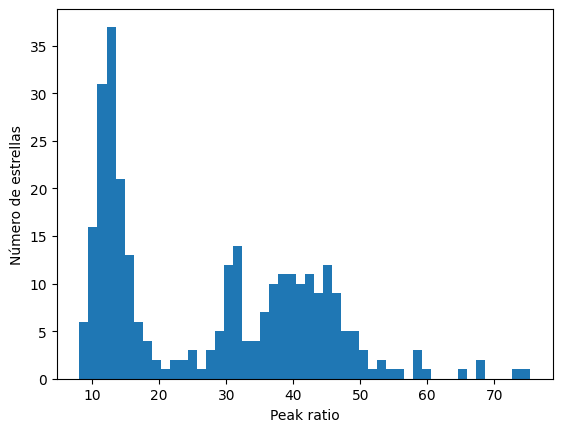

In [30]:
all_ratios = [r["peak_ratio"] for r in results]

plt.hist(all_ratios, bins=50)
plt.xlabel("Peak ratio")
plt.ylabel("Número de estrellas")
plt.show()

In [31]:
n_select = 50

if len(good_results) < n_select:
    selected_stars = good_results
else:
    selected_stars = random.sample(good_results, n_select)

In [32]:
output_dir = "VVVResults"
os.makedirs(output_dir, exist_ok=True)

In [35]:

def plot_star_summary(result, index=None, save_path=None):

    t = result["t"]
    y = result["y"]
    frequency = result["frequency"]
    power = result["power"]
    period = result["period"]
    star_id = result["id"]

    fig, axs = plt.subplots(1, 3, figsize=(15, 4))

    # --- Curva de luz ---
    axs[0].scatter(t, y, s=10)
    axs[0].invert_yaxis()
    axs[0].set_xlabel("Tiempo (MJD)")
    axs[0].set_ylabel("Magnitud Ks")
    axs[0].set_title("Curva de luz")

    # --- Lomb-Scargle ---
    axs[1].plot(frequency, power)
    axs[1].set_xlabel("Frecuencia")
    axs[1].set_ylabel("Potencia")
    axs[1].set_title("Lomb-Scargle")

    # --- Curva plegada ---
    phase = ((t - t[0]) / period) % 1
    phase2 = np.concatenate([phase, phase + 1])
    y2 = np.concatenate([y, y])

    axs[2].scatter(phase2, y2, s=10)
    axs[2].invert_yaxis()
    axs[2].set_xlabel("Fase")
    axs[2].set_ylabel("Magnitud")
    axs[2].set_title(f"P = {period:.3f}")

    # --- título ---
    if index is not None:
        title = f"Estrella {index} (ID {star_id}) | P = {period:.4f} d | FAP = {result['fap']:.2e}"
    else:
        title = f"ID: {star_id}"

    plt.suptitle(title, fontsize=14)
    plt.tight_layout()

    if save_path is not None:
        plt.savefig(save_path, dpi=150)
        plt.close()
    else:
        plt.show()

In [36]:
for i, r in enumerate(selected_stars, start=1):
    filename = f"{output_dir}/Estrella_{i}.png"
    plot_star_summary(r, index=i, save_path=filename)


df = pd.DataFrame([
    {
        "estrella": i+1,
        "id": r["id"],
        "periodo": r["period"],
        "fap": r["fap"],
        "peak_ratio": r["peak_ratio"]
    }
    for i, r in enumerate(selected_stars)
])

df.to_csv(f"{output_dir}/catalogo_estrellas.csv", index=False)

print("✅ Proceso terminado. Resultados guardados en:", output_dir)

✅ Proceso terminado. Resultados guardados en: VVVResults
